# Deep Q Learning with Experience Replay

Original Article: https://arxiv.org/abs/1312.5602

**Abstract:**

> We present the first deep learning model to successfully learn control policies directly from high-dimensional sensory input using reinforcement learning. The model is a convolutional neural network, trained with a variant of Q-learning, whose input is raw pixels and whose output is a value function estimating future rewards. We apply our method to seven Atari 2600 games from the Arcade Learning Environment, with no adjustment of the architecture or learning algorithm. We find that it outperforms all previous approaches on six of the games and surpasses a human expert on three of them.

![alt text](../images/dql-with-er-algorithm.png)

Ref: https://www.youtube.com/watch?v=EUrWGTCGzlA

In [11]:
%pip install torch


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
from torch import nn
import torch.nn.functional as F
from collections import deque
import random
import gymnasium as gym
import numpy as np
import torch

from matplotlib import pyplot as plt


In [13]:
class DQN(nn.Module):
    """Deep Q Network"""

    def __init__(self, in_states: int, h1_nodes: int, out_actions: int):
        super().__init__()

        # Define network layers
        self.fc1 = nn.Linear(
            in_states, h1_nodes
        )  # Fully connected layer - input to the hidden layer
        self.out = nn.Linear(h1_nodes, out_actions)  # Ouput layer

    def forward(self, x):
        x = F.relu(self.fc1(x))  # Apply ReLU (Rectified Linear Unit) activation
        x = self.out(x)  # Calculate the output

        return x

In [14]:
# Define memory for Experience Replay
class ReplayMemory:
    def __init__(self, max_len):
        self.memory = deque([], maxlen=max_len)  # First in - first out when full

    def append(self, transition):
        self.memory.append(transition)  # Stores a experience

    def sample(self, sample_size):
        return random.sample(self.memory, sample_size)  # Sample

    def __len__(self):
        return len(self.memory)

In [23]:
# Deep Q Learning
class FrozenLakeDQL:
    # Hyperparameters (Adjustable)
    learning_rate_a = 0.001     # learning rate (alpha)
    discount_factor_g = 0.9     # discount rate (gamma)
    network_sync_rate = 10      # number of steps the agent takes before syncing the policy and target network
    replay_memory_size = 1000   # size of replay memory
    mini_batch_size = 32        # size of the training data set sampled from the replay memory

    policy_weights_biases_path = "../data/fl_DQN.pt" # Path for DQN weights and biases

    # Neura Network
    loss_fn = (
        nn.MSELoss()
    )                   # NN Loss function. MSE = Mean Squared Error - can be swapped to something else
    optimizer = None    # NN Optimizer - Initialized later

    ACTIONS = [
        "L",
        "D",
        "R",
        "U",
    ]  # For printing - 0,1,2,3 maps to L(eft), D(own), R(ight), U(p)

    # Train the Frozen Lake environment
    def train(self, episodes, render=False, is_slippery=False, env_map_name="4x4", env_name = "FrozenLake-v1"):
        self.env_map_name = env_map_name
        self.env_name = env_name
        # Create enviroment - Frozen Lake instance
        env = gym.make(
            self.env_name,
            map_name=self.env_map_name,
            is_slippery=is_slippery,
            render_mode="human" if render else None,
        )
        num_states = env.observation_space.n
        num_actions = env.action_space.n

        epsilon = 1  # 1 = 100% random actions

        memory = ReplayMemory(self.replay_memory_size)

        # Create policy and target network. Number of nodes in the Hidden layer can be adjusted.
        policy_dqn = DQN(
            in_states=num_states, h1_nodes=num_states, out_actions=num_actions
        )
        target_dqn = DQN(
            in_states=num_states, h1_nodes=num_states, out_actions=num_actions
        )

        # Make the target and policy networks te same (copy weights and biases from one to the other)
        target_dqn.load_state_dict(policy_dqn.state_dict())

        print("Policy (random, before training):")
        self.print_dqn(policy_dqn)

        # Policy network optimizer. "Adam" optimizer can be swapped to something else.
        self.optimizer = torch.optim.Adam(
            policy_dqn.parameters(), lr=self.learning_rate_a
        )

        # List to keep track of rewards collected per episode. Initialize list to 0's.
        rewards_per_episode = np.zeros(episodes)

        # List to keep track of epsilon decay
        epsilon_history = []

        # Track number of steps taken. Used for syncing policy => target network.
        step_count = 0

        for i in range(episodes):
            state, info = env.reset()

            terminated = False  # True when agent falls in a hole or reached goal
            truncated = False   # True when agent takes more than 200 actions

            # Agent navigates map until it falls into hole/reaches goal (terminated) or has katen 200 actions (truncated)
            while (not terminated and not truncated):

                # Select action based on epsilon-greedy
                # Actions: 0 = left, 1 = down, 2 = right, 3 = up
                if random.random() < epsilon:
                    # Select random action
                    action = env.action_space.sample()
                else:
                    # Select best action based on the policy network
                    with torch.no_grad():
                        action = policy_dqn(self.state_to_dqn_input(state, num_states)).argmax().item()
                
                # Execute action on environment (step)
                new_state, reward, terminated, truncated, info = env.step(action)

                # Save experience into memory
                memory.append((state, action, new_state, reward, terminated))

                # Move to the next state
                state = new_state

                # Increment step counter
                step_count +=1

            # Keep track of the rewards collected per episode.
            if reward != 0:
                rewards_per_episode[i] = reward

            # Check if have enough experience has been collected and if at least 1 reward has been collected
            if len(memory) > self.mini_batch_size and np.sum(rewards_per_episode) > 0:
                mini_batch = memory.sample(self.mini_batch_size)
                self.optimize(mini_batch, policy_dqn, target_dqn)

                # Decay epsilon
                epsilon = max(epsilon - 1/episodes, 0)
                epsilon_history.append(epsilon)

                # Copy policy network to target network after a certain number of steps
                if step_count > self.network_sync_rate:
                    target_dqn.load_state_dict(policy_dqn.state_dict())
                    step_count = 0
        
        # Close environment
        env.close()

        print("Trained Policy:")
        self.print_dqn(policy_dqn)

        # Save policy
        torch.save(policy_dqn.state_dict(), self.policy_weights_biases_path)

        
        # Create new graph 
        plt.figure(1)

        # Plot average rewards (Y-axis) vs episodes (X-axis)
        sum_rewards = np.zeros(episodes)
        for x in range(episodes):
            sum_rewards[x] = np.sum(rewards_per_episode[max(0, x-100):(x+1)])
        plt.subplot(121) # plot on a 1 row x 2 col grid, at cell 1
        plt.plot(sum_rewards)
        
        # Plot epsilon decay (Y-axis) vs episodes (X-axis)
        plt.subplot(122) # plot on a 1 row x 2 col grid, at cell 2
        plt.plot(epsilon_history)


    def optimize(self, mini_batch, policy_dqn, target_dqn):
        # Get number of imput nodes
        num_states = policy_dqn.fc1.in_features

        current_q_list = []
        target_q_list = []

        for state, action, new_state, reward, terminated in mini_batch:

            if terminated:
                # Agent eighter reached goal (reward = 1) or fell into hole (reward = 0)
                # When in a terminal state, target q value should be set to the reward
                target = torch.FloatTensor([reward])

            else:
                # Calculate target Q Value
                with torch.no_grad():
                        target = torch.FloatTensor(
                            reward + self.discount_factor_g * target_dqn(self.state_to_dqn_input(new_state, num_states)).max()
                        )

            # Get current set of Q Values
            current_q = policy_dqn(self.state_to_dqn_input(state, num_states))
            current_q_list.append(current_q)

            # Get the target set of Q Values
            target_q = target_dqn(self.state_to_dqn_input(state, num_states))
            target_q[action] = target
            target_q_list.append(target_q)

        # Compute the loss for the whole minibtach
        loss = self.loss_fn(torch.stack(current_q_list), torch.stack(target_q_list))
        
        # Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    # Run the FrozeLake environment with the learned policy
    def test(self, episodes, is_slippery=False, env_map_name="4x4", env_name="FrozenLake-v1"):
        # Create FrozenLake instance
        env = gym.make(env_name, map_name=env_map_name, is_slippery=is_slippery, render_mode='human')
        num_states = env.observation_space.n
        num_actions = env.action_space.n

        # Load learned policy
        policy_dqn = DQN(in_states=num_states, h1_nodes=num_states, out_actions=num_actions) 
        policy_dqn.load_state_dict(torch.load(self.policy_weights_biases_path))
        policy_dqn.eval()    # switch model to evaluation mode

        print('Policy (trained):')
        self.print_dqn(policy_dqn)

        for i in range(episodes):
            state, info = env.reset()  # Initialize to state 0
            terminated = False      # True when agent falls in hole or reached goal
            truncated = False       # True when agent takes more than 200 actions            

            # Agent navigates map until it falls into a hole (terminated), reaches goal (terminated), or has taken 200 actions (truncated).
            while(not terminated and not truncated):  
                # Select best action   
                with torch.no_grad():
                    action = policy_dqn(self.state_to_dqn_input(state, num_states)).argmax().item()

                # Execute action
                state,reward,terminated,truncated,_ = env.step(action)

        env.close()


    def state_to_dqn_input(self, state: int, num_states: int) -> torch.Tensor:
        """
        Converts an state (int) to a tensor representation.
        For example, the FrozenLake 4x4 map has 4x4=16 states numbered from 0 to 15.

        Parameters: state=1, num_states=16
        Return: tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        """
        input_tensor = torch.zeros(num_states)
        input_tensor[state] = 1
        return input_tensor

    # Print DQN: state, best action, q values
    def print_dqn(self, dqn):
        # Get number of input nodes
        num_states = dqn.fc1.in_features

        # Loop each state and print policy to console
        for s in range(num_states):
            #  Format q values for printing
            q_values = ""
            for q in dqn(self.state_to_dqn_input(s, num_states)).tolist():
                q_values += (
                    "{:+.2f}".format(q) + " "
                )  # Concatenate q values, format to 2 decimals
            q_values = q_values.rstrip()  # Remove space at the end

            # Map the best action to L D R U
            best_action = self.ACTIONS[
                dqn(self.state_to_dqn_input(s, num_states)).argmax()
            ]

            # Print policy in the format of: state, action, q values
            # The printed layout matches the FrozenLake map.
            print(f"{s:02},{best_action},[{q_values}]", end=" ")
            if (s + 1) % 4 == 0:
                print()  # Print a newline every 4 states


In [24]:
frozen_lake = FrozenLakeDQL()
is_slippery = False

Policy (random, before training):
00,D,[-0.08 +0.42 +0.16 +0.04] 01,D,[+0.02 +0.34 +0.16 +0.02] 02,D,[-0.03 +0.41 +0.14 +0.08] 03,D,[-0.02 +0.23 +0.20 +0.01] 
04,D,[+0.02 +0.20 +0.04 -0.03] 05,D,[+0.03 +0.37 +0.20 +0.07] 06,D,[+0.06 +0.19 +0.16 +0.04] 07,D,[+0.01 +0.24 +0.12 +0.02] 
08,D,[-0.03 +0.40 +0.09 -0.08] 09,D,[+0.02 +0.23 +0.18 -0.06] 10,D,[-0.04 +0.42 +0.15 +0.09] 11,D,[-0.05 +0.23 +0.21 +0.05] 
12,D,[+0.02 +0.32 +0.27 +0.05] 13,D,[-0.03 +0.27 +0.18 -0.05] 14,D,[-0.04 +0.28 +0.20 +0.06] 15,D,[+0.01 +0.37 +0.20 -0.01] 
Trained Policy:
00,D,[+0.51 +0.59 +0.47 +0.58] 01,L,[+0.53 +0.16 +0.45 +0.48] 02,D,[+0.43 +0.60 +0.40 +0.55] 03,U,[+0.48 +0.18 +0.33 +0.50] 
04,D,[+0.59 +0.66 -0.00 +0.55] 05,D,[+0.48 +0.60 +0.39 +0.52] 06,D,[+0.37 +0.78 +0.19 +0.47] 07,U,[+0.52 +0.36 +0.49 +0.63] 
08,R,[+0.68 +0.05 +0.73 +0.59] 09,D,[+0.65 +0.81 +0.81 +0.03] 10,D,[+0.76 +0.90 +0.05 +0.63] 11,U,[+0.40 +0.33 +0.48 +0.60] 
12,R,[+0.53 +0.41 +0.64 +0.56] 13,R,[+0.17 +0.78 +0.90 +0.58] 14,R,[+0.76 +

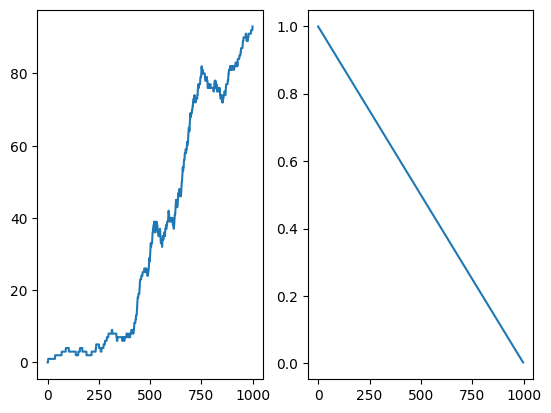

In [25]:
frozen_lake.train(1000, is_slippery=is_slippery)

In [27]:
frozen_lake.test(10, is_slippery=is_slippery)

Policy (trained):
00,D,[+0.51 +0.59 +0.47 +0.58] 01,L,[+0.53 +0.16 +0.45 +0.48] 02,D,[+0.43 +0.60 +0.40 +0.55] 03,U,[+0.48 +0.18 +0.33 +0.50] 
04,D,[+0.59 +0.66 -0.00 +0.55] 05,D,[+0.48 +0.60 +0.39 +0.52] 06,D,[+0.37 +0.78 +0.19 +0.47] 07,U,[+0.52 +0.36 +0.49 +0.63] 
08,R,[+0.68 +0.05 +0.73 +0.59] 09,D,[+0.65 +0.81 +0.81 +0.03] 10,D,[+0.76 +0.90 +0.05 +0.63] 11,U,[+0.40 +0.33 +0.48 +0.60] 
12,R,[+0.53 +0.41 +0.64 +0.56] 13,R,[+0.17 +0.78 +0.90 +0.58] 14,R,[+0.76 +0.86 +1.00 +0.88] 15,U,[+0.54 +0.52 +0.55 +0.56] 


Agora como Slippery ativado:

In [19]:
is_slippery = True

Policy (random, before training):
00,D,[+0.06 +0.19 +0.13 +0.07] 01,R,[+0.10 +0.19 +0.21 +0.08] 02,D,[+0.03 +0.17 +0.11 +0.05] 03,D,[+0.08 +0.16 +0.16 +0.08] 
04,D,[+0.03 +0.14 +0.07 -0.01] 05,D,[+0.09 +0.23 +0.15 +0.08] 06,R,[+0.03 +0.06 +0.10 +0.07] 07,D,[+0.01 +0.21 +0.15 +0.04] 
08,R,[+0.08 +0.11 +0.15 +0.04] 09,D,[+0.04 +0.19 +0.12 +0.05] 10,D,[+0.07 +0.24 +0.22 +0.06] 11,D,[+0.04 +0.19 +0.09 +0.08] 
12,D,[-0.04 +0.10 +0.07 +0.02] 13,R,[+0.11 +0.13 +0.17 +0.06] 14,R,[+0.10 +0.14 +0.22 +0.05] 15,D,[+0.06 +0.12 +0.07 +0.07] 
Trained Policy:
00,D,[+0.07 +0.07 +0.05 +0.06] 01,U,[+0.06 +0.04 +0.02 +0.06] 02,L,[+0.08 +0.08 +0.06 +0.06] 03,U,[+0.06 +0.04 +0.00 +0.06] 
04,L,[+0.09 +0.06 +0.01 +0.04] 05,D,[+0.15 +0.26 +0.13 +0.18] 06,L,[+0.12 +0.07 +0.10 +0.03] 07,D,[+0.04 +0.13 +0.06 +0.07] 
08,U,[+0.08 +0.10 +0.08 +0.12] 09,D,[+0.17 +0.21 +0.16 +0.11] 10,L,[+0.29 +0.21 +0.20 +0.11] 11,D,[+0.11 +0.23 +0.05 +0.14] 
12,L,[+0.09 +0.08 +0.05 +0.03] 13,R,[+0.21 +0.26 +0.33 +0.28] 14,D,[+0.40 +

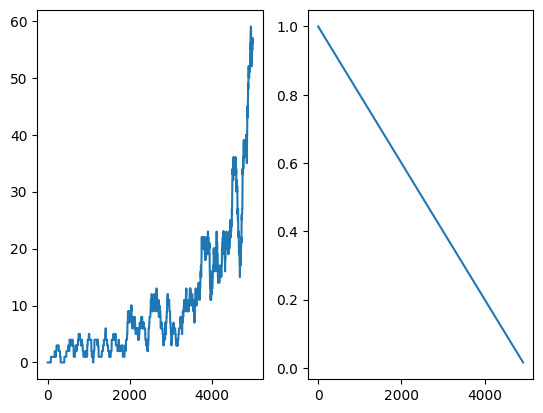

In [20]:
frozen_lake.train(5000, is_slippery=is_slippery)

In [21]:
frozen_lake.test(5)

Policy (trained):
00,D,[+0.07 +0.07 +0.05 +0.06] 01,U,[+0.06 +0.04 +0.02 +0.06] 02,L,[+0.08 +0.08 +0.06 +0.06] 03,U,[+0.06 +0.04 +0.00 +0.06] 
04,L,[+0.09 +0.06 +0.01 +0.04] 05,D,[+0.15 +0.26 +0.13 +0.18] 06,L,[+0.12 +0.07 +0.10 +0.03] 07,D,[+0.04 +0.13 +0.06 +0.07] 
08,U,[+0.08 +0.10 +0.08 +0.12] 09,D,[+0.17 +0.21 +0.16 +0.11] 10,L,[+0.29 +0.21 +0.20 +0.11] 11,D,[+0.11 +0.23 +0.05 +0.14] 
12,L,[+0.09 +0.08 +0.05 +0.03] 13,R,[+0.21 +0.26 +0.33 +0.28] 14,D,[+0.40 +0.62 +0.53 +0.56] 15,U,[+0.16 +0.18 +0.09 +0.19] 


KeyboardInterrupt: 

Policy (random, before training):
00,D,[-0.04 +0.05 -0.11 -0.07] 01,L,[-0.04 -0.06 -0.11 -0.07] 02,D,[-0.09 +0.05 -0.10 -0.11] 03,D,[-0.07 +0.03 -0.09 -0.06] 
04,D,[-0.03 +0.05 -0.11 -0.04] 05,D,[-0.09 +0.10 -0.09 -0.13] 06,D,[-0.05 +0.06 -0.07 -0.11] 07,D,[-0.03 +0.04 -0.12 -0.06] 
08,D,[-0.04 +0.04 -0.09 -0.09] 09,D,[-0.10 +0.06 -0.07 -0.11] 10,D,[-0.07 +0.08 -0.11 -0.11] 11,D,[-0.06 +0.09 -0.15 -0.07] 
12,D,[-0.06 +0.05 -0.12 -0.12] 13,D,[-0.06 +0.08 -0.08 -0.10] 14,D,[-0.07 +0.09 -0.10 -0.13] 15,D,[-0.05 +0.03 -0.07 -0.07] 
16,D,[-0.08 +0.02 -0.11 -0.11] 17,D,[-0.05 +0.04 -0.09 -0.08] 18,D,[-0.05 +0.08 -0.05 -0.12] 19,D,[-0.04 +0.06 -0.09 -0.12] 
20,D,[-0.04 +0.07 -0.05 -0.08] 21,D,[-0.05 +0.07 -0.11 -0.13] 22,D,[-0.05 +0.02 -0.10 -0.11] 23,D,[-0.06 +0.04 -0.07 -0.10] 
24,D,[-0.07 +0.04 -0.10 -0.08] 25,D,[-0.09 +0.07 -0.07 -0.08] 26,D,[-0.04 +0.08 -0.09 -0.09] 27,D,[-0.06 +0.06 -0.11 -0.07] 
28,D,[-0.05 +0.05 -0.08 -0.11] 29,D,[-0.07 +0.07 -0.06 -0.06] 30,D,[-0.06 +0.09 -0.06 -0.09

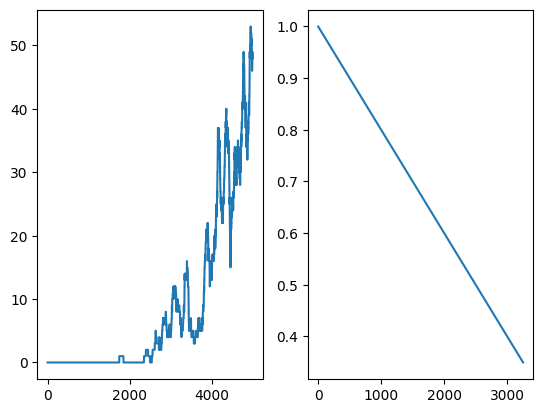

In [28]:
frozen_lake.train(5000, is_slippery=is_slippery, env_map_name="8x8")

In [30]:
frozen_lake.test(5, is_slippery=is_slippery, env_map_name="8x8")

Policy (trained):
00,R,[+0.27 +0.28 +0.29 +0.26] 01,D,[+0.25 +0.30 +0.28 +0.28] 02,D,[+0.29 +0.31 +0.29 +0.30] 03,D,[+0.32 +0.35 +0.34 +0.32] 
04,D,[+0.33 +0.40 +0.40 +0.36] 05,D,[+0.36 +0.44 +0.42 +0.39] 06,D,[+0.41 +0.50 +0.46 +0.43] 07,D,[+0.45 +0.51 +0.45 +0.45] 
08,D,[+0.28 +0.30 +0.29 +0.25] 09,R,[+0.27 +0.33 +0.34 +0.28] 10,R,[+0.30 +0.35 +0.36 +0.31] 11,R,[+0.33 -0.01 +0.38 +0.32] 
12,D,[+0.40 +0.44 +0.43 +0.36] 13,D,[+0.40 +0.48 +0.47 +0.39] 14,D,[+0.46 +0.51 +0.50 +0.42] 15,D,[+0.48 +0.60 +0.52 +0.48] 
16,R,[+0.30 +0.32 +0.33 +0.28] 17,D,[+0.30 +0.35 +0.33 +0.29] 18,D,[+0.33 +0.37 -0.01 +0.33] 19,D,[+0.31 +0.44 +0.36 +0.34] 
20,D,[+0.01 +0.48 +0.48 +0.38] 21,R,[+0.44 -0.01 +0.50 +0.44] 22,D,[+0.50 +0.57 +0.57 +0.50] 23,D,[+0.54 +0.66 +0.57 +0.52] 
24,R,[+0.32 +0.28 +0.34 +0.29] 25,R,[+0.33 +0.32 +0.37 +0.32] 26,R,[+0.35 +0.36 +0.42 +0.34] 27,R,[+0.40 +0.01 +0.44 +0.00] 
28,D,[+0.43 +0.51 -0.01 +0.44] 29,R,[+0.29 +0.40 +0.43 +0.41] 30,R,[+0.02 +0.63 +0.63 +0.52] 31,D,[+0.59 +0